## Common Imports

In [1]:
## Common Imports
from src.barbara_functions_for_notebooks_1_2_3_4_5 import filter_ra_only, export_to_csv
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from src.barbara_functions_for_notebooks_1_2_3_4_5 import load_autoimmune_data, get_duplicate_patient_ids, \
    get_duplicate_values, check_duplicate_protein_ids, transpose_autoimmune_data, split_bl_m6, harmonisation_validator
from src.barbara_functions_for_notebooks_1_2_3_4_5 import plot_global_distribution, compute_global_skewness, \
    compute_global_range, compute_quantiles, log_transform_assessment, plot_protein_distributions, protein_skewness, \
    protein_outlier_summary, log_normalise

## Define directory and file paths

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "datasets"
INITIAL_AUTOIMMUNE_FILE = "1_Initial_Autoimmune.xlsx"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY = "2_Initial_Autoimmune_RA_Only.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED = "3_Initial_Autoimmune_RA_Only_Transposed.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL = "4_Initial_Autoimmune_RA_Only_Transposed_BL.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_M6 = "5_Initial_Autoimmune_RA_Only_Transposed_M6.csv"
from pathlib import Path

print(Path.cwd())
print(Path(DATA_DIR))
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\notebooks\preprocessing
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv


## Load the Baseline (BL) dataset that has already been harmonised, to normalise by transforming logarithmically

In [3]:
bl_dataset = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL)
bl_dataset.head()

Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\4_Initial_Autoimmune_RA_Only_Transposed_BL.csv
Shape: (265, 163)
Index name: Patient_Timepoint


,104740305_XRCC6,104741891_SNRPD1,104742995_ACTB,104743232_PTBP1,104743420_FEN1,104743520_EIF4H,104745245_TNC,104745249_IGF1,104745436_FN1,104745443_IGFBP2,...,APOH_1113180421_APOH,HN1L_1043144040_HN1L,HNRNPA1_1066859223_HNRNPA1,HNRNPA2B1_1066866713_HNRNPA2B1,KDM6B_0172047444_KDM6B,KDM6B_1113180399_KDM6B,MVP_1066863544_MVP,NONO_0105507292_NONO,TMPO_1066866329_TMPO,ZNF574_1066529052_ZNF574
Patient_Timepoint,,,,,,,,,,,,,,,,,,,,,
TAC1241_BL,116.5,414.0,335.0,254.0,95.0,597.0,289.5,450.0,250.5,712.0,...,168.0,46.0,264.0,171.0,103.0,81.0,2064.0,172.0,134.5,103.0
TAC1147_BL,181.5,76.0,236.5,102.5,53.0,130.0,136.0,91.0,167.0,332.0,...,243.0,37.0,103.0,111.0,44.0,61.5,9449.0,276.0,38.0,87.0
TAC1094_BL,269.5,424.0,252.5,309.5,166.5,701.5,284.0,537.0,280.0,854.0,...,261.0,97.0,362.0,257.0,117.0,147.0,2128.0,192.0,171.0,140.0
TAC1272_BL,159.0,194.0,799.0,156.0,56.0,345.5,271.0,242.0,419.0,654.5,...,106.0,55.5,1395.0,198.5,96.5,56.0,6695.5,473.0,88.0,137.0
TAC1096_BL,209.0,82.0,245.0,95.0,43.0,153.0,80.0,119.0,138.0,174.5,...,63.0,83.0,79.5,66.0,292.0,541.0,4639.0,242.0,41.0,250.5


## Normalise the data using log transformation to reduce skewness and make the distribution more symmetric

In [4]:
bl_dataset_log = log_normalise(bl_dataset)
bl_dataset_log.head()
#pca_A = run_pca_visualisation(df_log)

Log normalisation complete
Shape: (265, 163)


,104740305_XRCC6,104741891_SNRPD1,104742995_ACTB,104743232_PTBP1,104743420_FEN1,104743520_EIF4H,104745245_TNC,104745249_IGF1,104745436_FN1,104745443_IGFBP2,...,APOH_1113180421_APOH,HN1L_1043144040_HN1L,HNRNPA1_1066859223_HNRNPA1,HNRNPA2B1_1066866713_HNRNPA2B1,KDM6B_0172047444_KDM6B,KDM6B_1113180399_KDM6B,MVP_1066863544_MVP,NONO_0105507292_NONO,TMPO_1066866329_TMPO,ZNF574_1066529052_ZNF574
Patient_Timepoint,,,,,,,,,,,,,,,,,,,,,
TAC1241_BL,4.766438,6.028279,5.817111,5.541264,4.564348,6.393591,5.671604,6.111467,5.527443,6.569481,...,5.129899,3.850148,5.579730,5.147494,4.644391,4.406719,7.632886,5.153292,4.908972,4.644391
TAC1147_BL,5.206750,4.343805,5.470168,4.639572,3.988984,4.875197,4.919981,4.521789,5.123964,5.808142,...,5.497168,3.637586,4.644391,4.718499,3.806662,4.135167,9.153770,5.624018,3.663562,4.477337
TAC1094_BL,5.600272,6.052089,5.535364,5.738184,5.120983,6.554645,5.652489,6.287859,5.638355,6.751101,...,5.568345,4.584967,5.894403,5.552960,4.770685,4.997212,7.663408,5.262690,5.147494,4.948760
TAC1272_BL,5.075174,5.273000,6.684612,5.056246,4.043051,5.847883,5.605802,5.493061,6.040255,6.485398,...,4.672829,4.034241,7.241366,5.295814,4.579852,4.043051,8.809340,6.161207,4.488636,4.927254
TAC1096_BL,5.347108,4.418841,5.505332,4.564348,3.784190,5.036953,4.394449,4.787492,4.934474,5.167639,...,4.158883,4.430817,4.388257,4.204693,5.680173,6.295266,8.442470,5.493061,3.737670,5.527443


## Verify successful normalisation by re-assessing the global distribution and skewness after log transformation

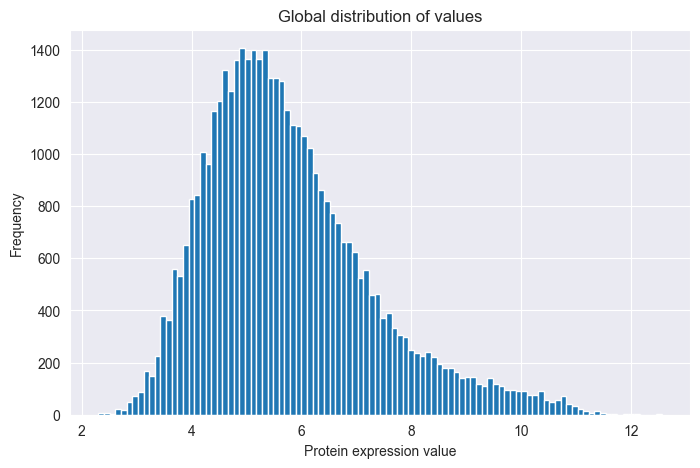


===== GLOBAL DISTRIBUTION SUMMARY =====
Skewness: 0.933
Min: 2.302585092994046
Max: 12.568661567376834

Quantiles:
0.01     3.237490
0.05     3.761200
0.50     5.497168
0.95     8.787068
0.99    10.353791
dtype: float64


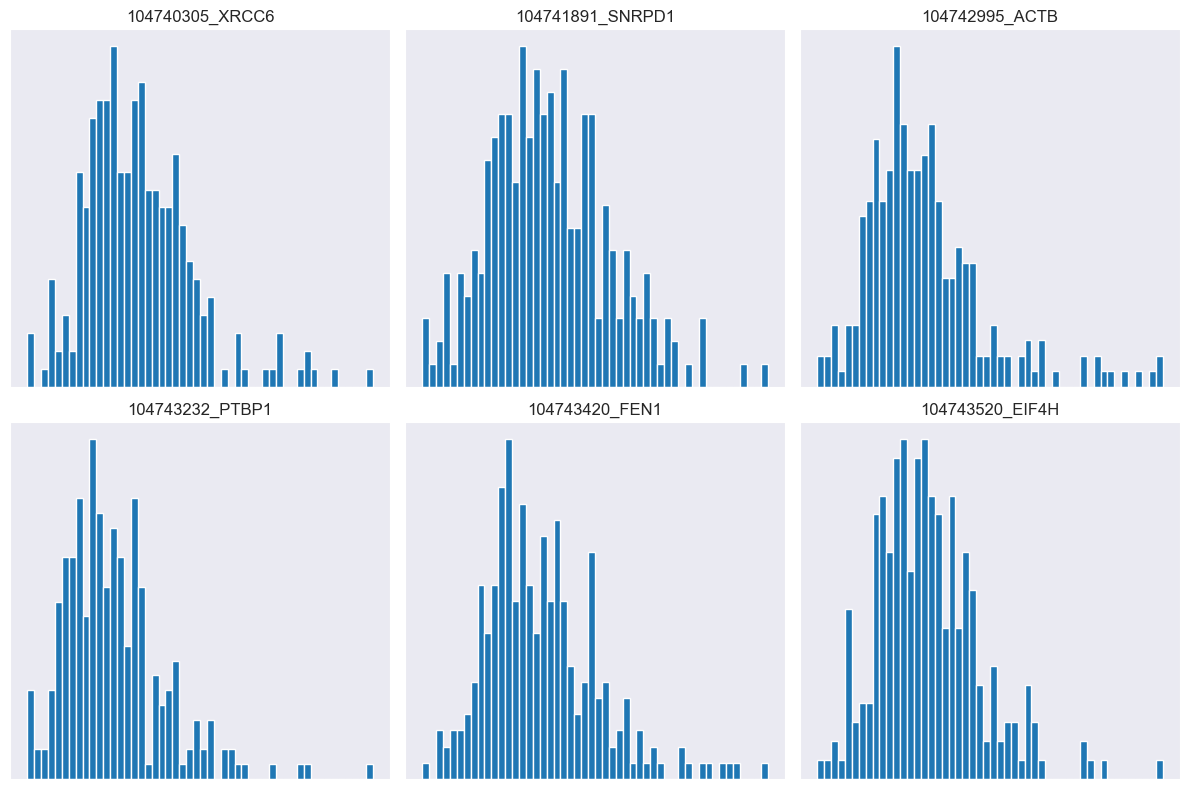

Index(['104740305_XRCC6', '104741891_SNRPD1', '104742995_ACTB',
       '104743232_PTBP1', '104743420_FEN1', '104743520_EIF4H', '104745245_TNC',
       '104745249_IGF1', '104745436_FN1', '104745443_IGFBP2', '104745679_SPP1',
       '104745733_VIM', '105481183_TRAF3IP3', '105481284_RPLP2',
       '105482048_ENO1', '105483201_NPM1', '105483601_CLU', '105484159_SP100',
       '105486564_DDX21', '105487234_DLST'],
      dtype='str')
Number of proteins: 163
count    163.000000
mean       0.910592
std        0.605821
min       -0.548183
25%        0.494557
50%        0.897763
75%        1.221806
max        3.036503
dtype: float64
Proteins with skew > 1: 60
Proteins with skew > 2: 10
Total proteins: 163
104745436_FN1               3.036503
1066859503_ELANE            2.775935
1043170594_EHD1             2.531107
1066527143_SH3KBP1          2.464088
105481284_RPLP2             2.460272
1113172457_RPLP1            2.142004
1047888625_RPLP0            2.048468
105489246_MS4A1             2.020744

In [5]:
# Plot global distribution
plot_global_distribution(bl_dataset_log)

# Plot protein distribution
plot_protein_distributions(bl_dataset_log)
print(bl_dataset_log.columns[:20])


# Check skewness for each protein
print("Number of proteins:", len(bl_dataset_log.columns))
skew = protein_skewness(bl_dataset_log)
skew = protein_skewness(bl_dataset_log)
print(skew.describe())
print("Proteins with skew > 1:", (skew > 1).sum())
print("Proteins with skew > 2:", (skew > 2).sum())
print("Total proteins:", len(skew))
print(skew.head(40))

## Export the log-normalised dataset as .csv for use in the post-normalisation visualisations

In [6]:
export_to_csv(bl_dataset_log, f"{DATA_DIR}/6_Initial_Autoimmune_RA_Only_Transposed_BL_Log.csv")

File saved to: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets/6_Initial_Autoimmune_RA_Only_Transposed_BL_Log.csv
